--- Parâmetros Otimizados ---
Reação 1: A = 9.25e+11 h⁻¹, Ea = 150.40 kJ/mol
k = 6.79e-01 h⁻¹
Reação 2: A = 1.24e+12 h⁻¹, Ea = 154.51 kJ/mol
k = 2.37e-01 h⁻¹
Reação 3: A = 2.23e+13 h⁻¹, Ea = 170.42 kJ/mol
k = 2.87e-01 h⁻¹
Reação 4: A = 1.41e+11 h⁻¹, Ea = 140.69 kJ/mol
k = 5.31e-01 h⁻¹


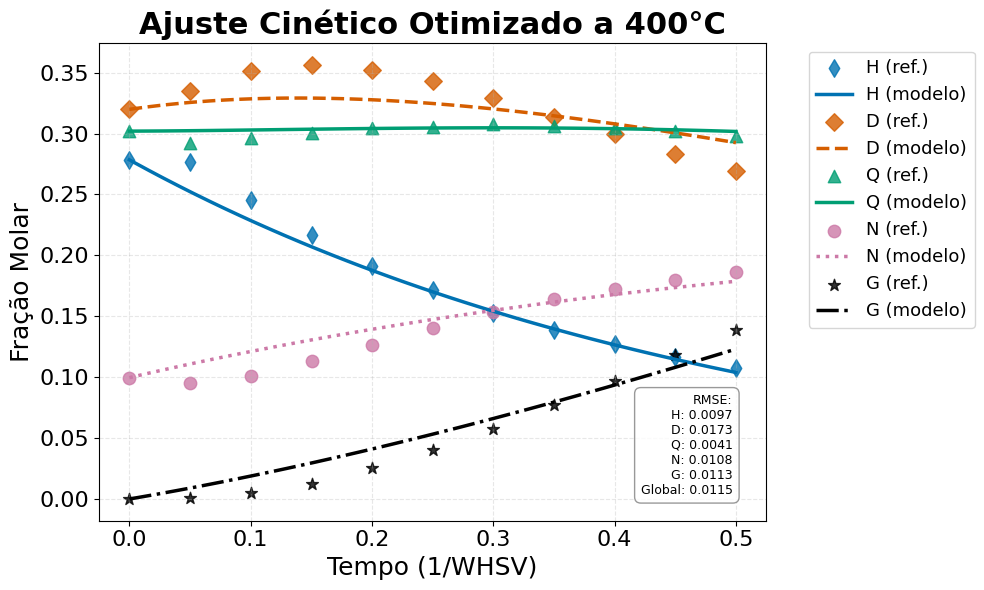

In [8]:
import pandas as pd
import numpy as np
from pyomo.environ import *
from pyomo.dae import *
import matplotlib.pyplot as plt

# 1. Carregar dados e verificar colunas
# O usuário disse que mudou para H, D, Q, N, G. O tempo deve ser 'x'.
file_name = 'dados.xlsx'
df = pd.read_excel(file_name)

# Colunas esperadas
lumps = ['H', 'D', 'Q', 'N', 'G']
R = 8.314 / 1000 # kJ/mol.K
T = 400 + 273.15

# Normalização: soma de cada linha = 1.0
df[lumps] = df[lumps].div(df[lumps].sum(axis=1), axis=0)

t_exp = df['x'].values
dados_exp = {lump: df[lump].values for lump in lumps}
val_iniciais = {lump: dados_exp[lump][0] for lump in lumps}

# 2. Modelo Pyomo para Estimação
def solve_estimation(temp_celsius):
    m = ConcreteModel()
    R = 8.314 / 1000 # kJ/mol.K
    T = temp_celsius + 273.15
    
    m.t = ContinuousSet(initialize=t_exp)
    m.lump = Set(initialize=lumps)
    
    # Parâmetros a estimar
    m.lnA = Var(RangeSet(1, 4), initialize=15.0, bounds=(5, 50))
    m.Ea = Var(RangeSet(1, 4), initialize=80.0, bounds=(30, 250))
    
    m.C = Var(m.lump, m.t, within=NonNegativeReals)
    m.dCdt = DerivativeVar(m.C, wrt=m.t)
    
    def _k(m, i):
        return exp(m.lnA[i] - m.Ea[i] / (R * T))
        
    def _balanco(m, l, t):
        if l == 'H': return m.dCdt[l,t] == -_k(m, 1)*m.C[l,t]
        if l == 'D': return m.dCdt[l,t] == _k(m, 1)*m.C['H',t] - _k(m, 2)*m.C[l,t]
        if l == 'Q': return m.dCdt[l,t] == _k(m, 2)*m.C['D',t] - _k(m, 3)*m.C[l,t]
        if l == 'N': return m.dCdt[l,t] == _k(m, 3)*m.C['Q',t] - _k(m, 4)*m.C[l,t]
        if l == 'G': return m.dCdt[l,t] == _k(m, 4)*m.C['N',t]
    m.ode = Constraint(m.lump, m.t, rule=_balanco)
    
    for l in lumps:
        m.C[l, 0].fix(val_iniciais[l])
        
    def _obj(m):
        return sum((m.C[l, t] - dados_exp[l][np.where(t_exp == t)[0][0]])**2 
                   for l in lumps for t in t_exp)
    m.obj = Objective(rule=_obj, sense=minimize)
    
    TransformationFactory('dae.collocation').apply_to(m, nfe=20, ncp=3)
    # No sandbox, não temos ipopt.exe com caminho absoluto. Usamos o comando direto.
    solver = SolverFactory('ipopt', executable=r'C:\zebra\ipopt.exe')
    solver.solve(m)
    return m

# Execução (usando 400C como exemplo padrão)
temp_exp = 400
model = solve_estimation(temp_exp)

# Resultados
print("--- Parâmetros Otimizados ---")
results_params = []
for i in range(1, 5):
    A = np.exp(value(model.lnA[i]))
    lnA = value(model.lnA[i])
    Ea = value(model.Ea[i])
    results_params.append({'Reacao': i, 'A': A, 'Ea': Ea})
    print(f"Reação {i}: A = {A:.2e} h⁻¹, Ea = {Ea:.2f} kJ/mol")
    DENOM = R*T
    K = lnA - Ea / DENOM
    print(f"k = {K:.2e} h⁻¹")

rmse_individuais = {}
todos_residuos_quadrados = []

for l in lumps:
    residuos_lump = []
    for i, t in enumerate(t_exp):
        y_calc = value(model.C[l, t])
        y_exp = dados_exp[l][i]
        erro_sq = (y_calc - y_exp)**2
        residuos_lump.append(erro_sq)
        todos_residuos_quadrados.append(erro_sq)
    
    rmse_individuais[l] = np.sqrt(np.mean(residuos_lump))

rmse_global = np.sqrt(np.mean(todos_residuos_quadrados))

# --- 2. Preparação do Texto para o Gráfico ---
# Criando uma string formatada com os resultados
texto_rmse = "RMSE:\n"
for l in lumps:
    texto_rmse += f"{l}: {rmse_individuais[l]:.4f}\n"
texto_rmse += f"Global: {rmse_global:.4f}"

texto_rmse = "RMSE:\n"
for l in lumps:
    texto_rmse += f"{l}: {rmse_individuais[l]:.4f}\n"
texto_rmse += f"Global: {rmse_global:.4f}"

plt.figure(figsize=(10, 6))

# Configurações globais de fonte e tamanho
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.titlesize'] = 22
plt.rcParams['axes.labelsize'] = 18
plt.rcParams['xtick.labelsize'] = 16
plt.rcParams['ytick.labelsize'] = 16
plt.rcParams['legend.fontsize'] = 13  # Tamanho ideal para caber bem dentro do quadro
plt.rcParams['lines.linewidth'] = 3.5

t_plot = sorted(list(model.t))

# Dicionário atualizado com a paleta Okabe-Ito (Acessível para daltônicos)
estilos = {
    'H': ('#0072B2', 'd', '-'),   # Azul Escuro
    'D': ('#D55E00', 'D', '--'),  # Vermelho-alaranjado
    'Q': ('#009E73', '^', '-'),   # Verde-azulado
    'N': ('#CC79A7', 'o', ':'),   # Púrpura
    'G': ('#000000', '*', '-.')   # Preto
}

for l in lumps:
    color, marker, ls = estilos[l]
    plt.scatter(t_exp, dados_exp[l], color=color, marker=marker, alpha=0.8, s=80, label=f'{l} (ref.)')
    plt.plot(t_plot, [value(model.C[l, t]) for t in t_plot], color=color, linestyle=ls, label=f'{l} (modelo)', linewidth=2.5)

# Adicionando o texto no canto inferior direito (lower right)
# O bbox cria a caixinha ao redor do texto para facilitar a leitura
plt.text(0.95, 0.05, texto_rmse, transform=plt.gca().transAxes, 
         fontsize=9, verticalalignment='bottom', horizontalalignment='right',
         bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.8, edgecolor='gray'))

plt.title(f"Ajuste Cinético Otimizado a {temp_exp}°C", fontweight='bold')
plt.xlabel("Tempo (1/WHSV)")
plt.ylabel("Fração Molar")

# Legenda do lado de fora
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3, linestyle='--') # Deixei o grid levemente mais visível e tracejado
plt.tight_layout()

# SALVAMENTO: bbox_inches='tight' garante que a legenda externa não seja cortada!
plt.savefig('modelo_simplificado.png', dpi=1200, bbox_inches='tight')
plt.show()
# Salvar parâmetros em CSV para o usuário
pd.DataFrame(results_params).to_csv('parametros_otimizados.csv', index=False)